# The Spelled-Out Backpropagation: Building Micrograd

This notebook follows Andrej Karpathy's ["Zero to Hero" lecture on building a tiny autograd engine from scratch](https://www.youtube.com/watch?v=VMj-3S1tku0).

### What is Micrograd?
Micrograd is a tiny Autograd (automatic gradient) engine. It implements backpropagation (evaluation of derivatives/gradients along a computational graph) over a dynamically built DAG (directed acyclic graph). By building it, we understand the core mechanics of how modern neural network libraries (like PyTorch) compute gradients under the hood.

---

In [41]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [11]:
import os
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'


## Part 1: Derivatives and their Intuition

We begin with a basic single-variable function $f(x) = 3x^2 - 4x + 5$ and explore the definition of a derivative:
$$\lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$
This measures the rate of change of the output when the input is tweaked by a tiny amount $h$.

In [2]:
def f(x):
    return 3*x**2 -4*x +5

In [3]:
f(3.0)

20.0

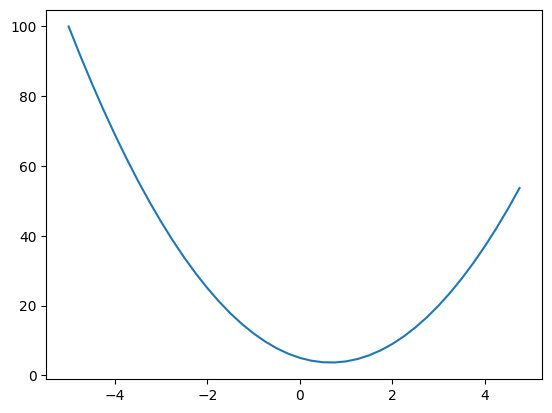

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.000001
x = 2/3
(f(x + h) - f(x))/h
#the slope is zero

2.999378523327323e-06

## Part 2: Derivatives with Multiple Inputs

Now let's examine functions that take multiple inputs (e.g. $d = a \times b + c$) and see how tweaking any of the individual inputs propagates to change the final output.

In [6]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


## Part 3: Building the `Value` Object

To build neural networks, we need to represent a computational graph dynamically. We wrap numbers in a custom `Value` class that keeps track of:
1. `data`: The raw numeric value (forward pass).
2. `grad`: The derivative of the final output with respect to this value (initialized to `0.0`).
3. `_prev`: The child nodes that produced this value.
4. `_op`: The math operation that created it.

In [117]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()



## Part 4: Visualizing the Computational Graph

We define helper functions (`trace` and `draw_dot`) using Graphviz to render mathematical expressions as a directed acyclic graph (DAG). This makes it easy to visualize both the forward values and the backpropagated gradients.

In [13]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

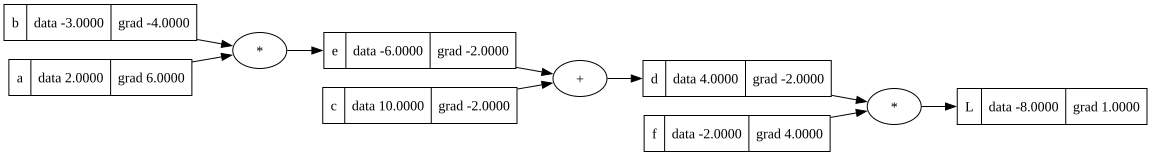

In [35]:
draw_dot(L)

## Part 5: Manual Backpropagation (Chain Rule)

Here, we manually calculate the derivative of the output $L$ with respect to every single variable ($a, b, c, d, e, f$) using the **Chain Rule**:
$$\frac{d L}{d x} = \frac{d L}{d y} \cdot \frac{d y}{d x}$$
We initialize $L.grad = 1$ and work our way backward.

In [34]:
L.grad=1
f.grad=4.0
d.grad= -2.0
c.grad=-2.0*1
e.grad=-2.0*1
a.grad=-2.0*-3.0
b.grad= -2.0*2.0

dd/dc =?

d = c+e
dd/dc =1.0 and dd/de=1.0
by chain rule of calculus, we can extract dL / dc= (dL/ dd) *(dd / dc)

Know:
dL/ dd
dd / dc

dl /de =-2.0
Now we have to find dL/ da = (dL / de )*(de /d a) = (-2.0*-3) =6

e=a*b
de/da = b
de/db= a


### Nudging the Inputs

Let's verify our manual gradient computations by slightly adjusting the leaf variables in the direction of their gradients, and observing if the output $L$ increases as expected.

In [38]:
#now we will be nudging our ouput in the direction of the gradient
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
f.data += 0.01*f.grad


e=a*b; e.label='e'
d=e +c; d.label='d'
L=d*f;L.label='L'

print(L.data)

-7.286496


In [37]:
def lol():

    h=0.00001

    a= Value(2.0, label='a')
    b = Value (-3.0, label='b')
    c= Value(10.0, label='c')
    e=a*b; e.label='e'
    d=e +c; d.label='d'
    f=Value(-2.0, label='f')
    L=d*f;L.label='L'
    L1=L.data

    a= Value(2.0, label='a')
    b = Value (-3.0, label='b')
    c= Value(10.0, label='c')
    b.data+=h
    e=a*b; e.label='e'
    d=e +c; d.label='d'
   # d.data+=h
    f=Value(-2.0, label='f')
    L=d*f;L.label='L'
    L2=L.data

    print((L2-L1)/h)

lol()


-4.000000000026205


## Part 6: A More Complex Example (Neuron with tanh Activation)

Now let's build a single neuron with two inputs ($x_1, x_2$), weights ($w_1, w_2$), a bias $b$, and a $\tanh$ activation function.

The equation is:
$$o = \tanh(x_1 w_1 + x_2 w_2 + b)$$

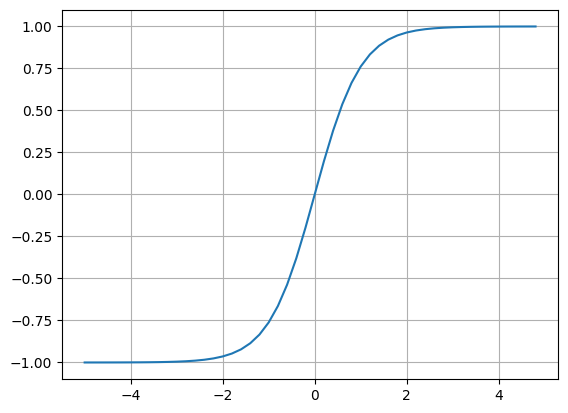

In [39]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [89]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'



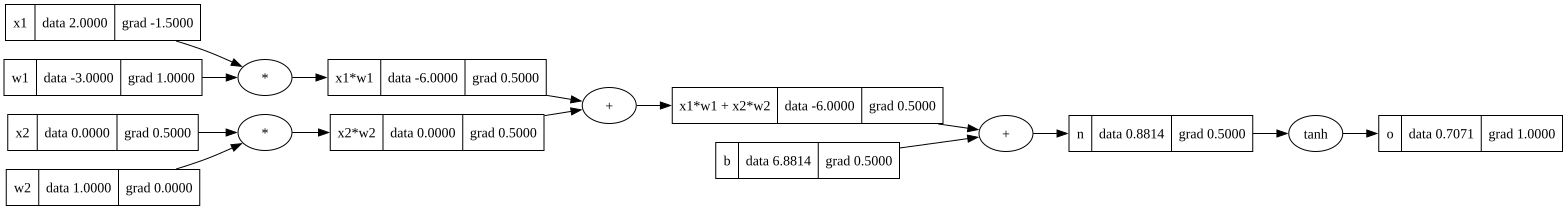

In [92]:
draw_dot(o)

### Manual Backpropagation through the Neuron

We manually write out the backpropagation steps for the entire neuron. We compute the local derivative of the activation function:
$$\frac{d}{dx}(\tanh(x)) = 1 - \tanh^2(x)$$
and pass gradients backward.

In [50]:
o.grad = 1.0

In [53]:
#o =tanh(n)
# do/dn = 1- tanh(n)**2
1-o.data**2
n.grad =0.5

In [56]:

x1w1x2w2 .grad=0.5
b.grad=0.5

In [58]:
x1w1.grad=0.5
x2w2.grad=0.5


In [60]:
x2.grad=w2.data*x2w2.grad
w2.grad=x2.data*x2w2.grad

In [62]:
x1.grad=w1.data*x1w1.grad
w1.grad=x1.data*x1w1.grad

In [74]:
o.grad=1

## Part 7: Automating Backpropagation

Instead of writing out backpropagation steps by hand, we define a local `_backward` function for each mathematical operation in the `Value` class, allowing the chain rule to run automatically at each node.

In [75]:
#now we will be using the backward function inside the value class

o._backward()

In [77]:
n._backward()

In [79]:
b._backward()# b doesnot have anything backward
x1w1x2w2._backward()

In [81]:
x2w2._backward()
x1w1._backward()

### Topological Sort

To backpropagate correctly, we must process nodes in the reverse topological order (from outputs back to inputs). We define a topological sorting algorithm to order our graph nodes.

In [83]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [91]:
o.backward()

#figuring out a bug

## Part 8: The Gradient Accumulation Bug (Multivariate Chain Rule)

When a variable is used multiple times (e.g., $b = a + a$ or $b = a \times a$), the gradients flowing back to it along all paths must be added together. We resolve this by changing gradient updates in the operations from `=` (overwriting) to `+=` (accumulating).

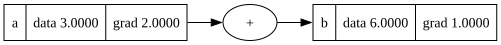

In [106]:
a= Value(3.0, label='a')
b = a+a; b.label='b'

b.backward()
draw_dot(b)

In [114]:
a= Value(2.0)
3*a

Value(data=6.0)

## Part 9: Comparing with PyTorch

To verify the correctness of our autograd engine, we implement the exact same neural structure in PyTorch and compare the calculated gradients.

In [121]:
#!pip install torch
import torch
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


## Part 10: Building a Multi-Layer Perceptron (MLP)

Using our `Value` class, we build full neural network layers:
1. **Neuron**: Takes inputs, computes $\sum w_i x_i + b$, and applies a tanh activation.
2. **Layer**: A collection of Neurons executing in parallel.
3. **MLP**: Multiple Layers stacked sequentially.

In [124]:
import random
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [125]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.8902339565178891)

## Part 11: Dataset, Predictions, and Mean Squared Error Loss

We define a small binary classification dataset with 4 inputs and 4 labels. We define a Mean Squared Error (MSE) loss function to calculate how far our MLP predictions are from the true labels:
$$\text{Loss} = \sum (y_{\text{pred}} - y)^2$$

In [126]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

## Part 12: Optimization Loop (Gradient Descent)

We implement a standard training optimization loop:
1. **Forward Pass**: Compute the predictions and loss.
2. **Zero Gradients**: Reset all parameter gradients to 0.
3. **Backward Pass**: Call `.backward()` on the loss.
4. **Parameter Update**: Adjust weights and biases slightly in the negative direction of the gradient: $\text{param} = \text{param} - \text{learning\_rate} \times \text{grad}$.

In [127]:

for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)
  

0 7.314972696420259
1 2.516873703417378
2 3.564641487615494
3 0.3833987121801524
4 0.04056287968943682
5 0.0353901902002176
6 0.0315887137707835
7 0.028614119458768496
8 0.026190324770475698
9 0.024159921247632426
10 0.022424949216879833
11 0.020920191505107072
12 0.0195998834911733
13 0.01843055478900895
14 0.01738691128782923
15 0.016449330382523226
16 0.015602263105643797
17 0.014833172344629905
18 0.01413180218392896
19 0.013489659822895048


In [128]:
ypred

[Value(data=0.9322400928943416),
 Value(data=-0.9458746748143588),
 Value(data=-0.945148376245542),
 Value(data=0.9455940871138478)]